# Epochs — Final Model Evaluation

Evaluate the selected model on an artist-disjoint held-out test set, generate metrics/confusion matrix, and save the final pipeline.

In [1]:
from pathlib import Path
import json, joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

PROJECT_ROOT = Path.cwd().parent
df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "fma_features.csv")

ID_COLUMNS = ["track_id","artist_id","genre"]
feature_columns = [c for c in df.columns if c not in ID_COLUMNS]
X, y, groups = df[feature_columns], df["genre"], df["artist_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_artists = set(groups.iloc[train_idx])
test_artists = set(groups.iloc[test_idx])

print("Train:", len(X_train), "Test:", len(X_test))
print("Artist overlap:", len(train_artists & test_artists))


Train: 6485 Test: 1512
Artist overlap: 0


#### Run `04_model_training.ipynb` first in the same kernel/session, so `searches` contains the tuned candidates.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import joblib
from pathlib import Path

# Final model selected from Notebook 04
final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SVC(
        C=1,
        kernel="rbf",
        gamma="scale",
        probability=True,
        random_state=42
    ))
])

# Train on artist-disjoint training set
final_model.fit(X_train, y_train)

# Predict held-out test set
y_pred = final_model.predict(X_test)

# Final evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print("Final Model: SVM")
print("Parameters: C=1, kernel=rbf, gamma=scale")
print()
print(f"Test Accuracy:       {accuracy:.4f}")
print(f"Test Macro Precision:{precision:.4f}")
print(f"Test Macro Recall:   {recall:.4f}")
print(f"Test Macro F1:       {macro_f1:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Save final trained model
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "final_pipeline.joblib"
joblib.dump(final_model, model_path)

print(f"\nSaved final model: {model_path}")

Final Model: SVM
Parameters: C=1, kernel=rbf, gamma=scale

Test Accuracy:       0.4716
Test Macro Precision:0.4680
Test Macro Recall:   0.4829
Test Macro F1:       0.4697

Classification Report:
               precision    recall  f1-score   support

   Electronic       0.49      0.50      0.50       173
 Experimental       0.50      0.36      0.42       207
         Folk       0.59      0.50      0.54       209
      Hip-Hop       0.52      0.70      0.59       168
 Instrumental       0.43      0.59      0.50       137
International       0.40      0.40      0.40       180
          Pop       0.28      0.22      0.25       221
         Rock       0.53      0.58      0.56       217

     accuracy                           0.47      1512
    macro avg       0.47      0.48      0.47      1512
 weighted avg       0.47      0.47      0.46      1512


Saved final model: ..\models\final_pipeline.joblib


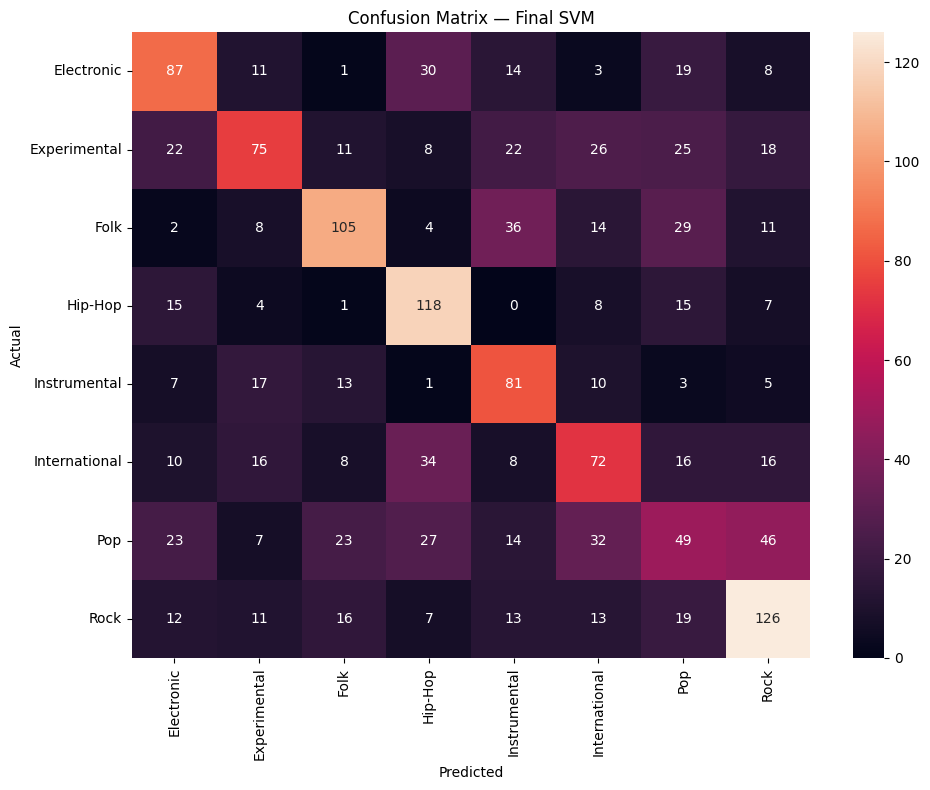

In [4]:
# Confusion Matrix
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Confusion Matrix — Final SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [5]:
metadata = {
    "model": "SVM",
    "parameters": {
        "C": 1,
        "kernel": "rbf",
        "gamma": "scale"
    },
    "feature_count": len(feature_columns),
    "features": feature_columns,
    "cv_macro_f1": 0.4726343023443146,
    "test_accuracy": float(accuracy),
    "test_macro_precision": float(precision),
    "test_macro_recall": float(recall),
    "test_macro_f1": float(macro_f1),
    "train_samples": len(X_train),
    "test_samples": len(X_test),
    "artist_overlap": 0
}

(MODEL_DIR / "model_metadata.json").write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8"
)

print("Saved:", MODEL_DIR / "model_metadata.json")

Saved: ..\models\model_metadata.json
